# Robust Sleep Staging under Distribution Shift

**Course**: AI for Medical Time Series  
**Dataset**: Sleep-EDF Expanded (PhysioNet) — https://physionet.org/content/sleep-edfx/1.0.0/  

**Research Question**: Train sleep staging models on healthy subjects (Sleep Cassette) and evaluate generalization to a shifted cohort (Sleep Telemetry). Quantify performance degradation under subject-level splits.

This notebook is an orchestrator for the workflow:

**Pipeline**:
1. **Preprocess** (filter, epoch)
2. **Feature extraction** with PSD and checkpointing
3. **Train** a classifier on SC (Sleep Cassette) and save the model checkpoint
4. **Evaluate** 
    - Evaluate in-distribution: SC → SC
    - Evaluate under distribution shift: SC → ST
    - Compare and analyze results


---

## 1. Imports & configuration

This notebook only orchestrates the pipeline. Each step delegates to a dedicated module in `rss/`.

In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


## 2. Dataset paths

The paths below point to the downloaded Sleep-EDF files and the checkpoint folders used for intermediate artifacts.

In [9]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


## 3. Data exploration & visualization

Before preprocessing, it helps to inspect one recording and the stage distribution. This keeps the dataset assumptions visible and makes distribution shift easier to explain.

In [10]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\E1024679\AppData\Local\Temp\ipykernel_17672\3121516847.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_17672\3121516847.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_17672\3121516847.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\E1024679\AppData\Local\Temp\ipykernel_17672\3121516847.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


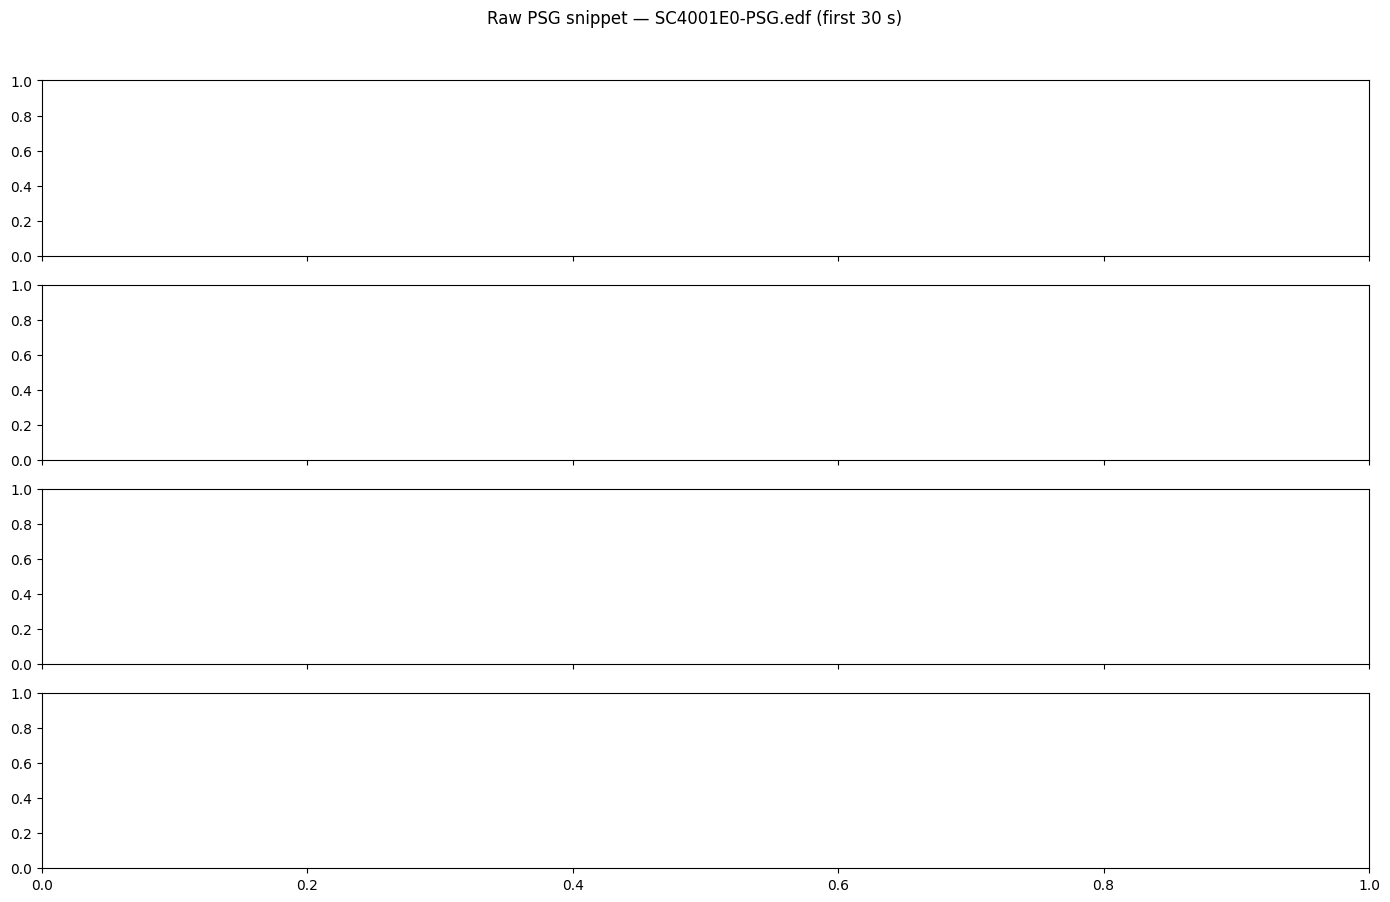

In [ ]:
# Plot a short raw-signal snippet from the first few available channels
channels_to_plot = raw.ch_names[: min(4, len(raw.ch_names))]
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info['sfreq'])
end_sample = int(end_sec * raw.info['sfreq'])
times = np.arange(start_sample, end_sample) / raw.info['sfreq']
data, _ = raw[: len(channels_to_plot), start_sample:end_sample]

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 2.2 * len(channels_to_plot)), sharex=True)
if len(channels_to_plot) == 1:
    axes = [axes]

for ax, channel, signal in zip(axes, channels_to_plot, data):
    ax.plot(times, signal, lw=0.7)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw PSG snippet — {example_psg.name} (first 30 s)', y=1.02)
plt.tight_layout()
plt.show()

Total annotated epochs: 154

Sleep stage distribution:
  Wake: 12 epochs (0.1h)
  N1: 24 epochs (0.2h)
  N2: 40 epochs (0.3h)
  N3: 71 epochs (0.6h)
  REM: 6 epochs (0.1h)


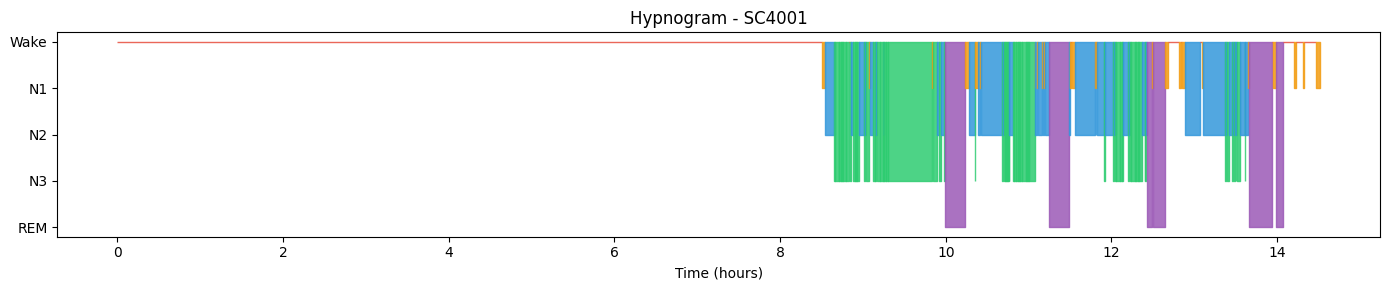

In [12]:
# Load and visualize hypnogram
annotations = mne.read_annotations(example_hyp)
stages = [preprocess.STAGE_MAP.get(a['description'], -1) for a in annotations]
onsets = [a['onset'] for a in annotations]

# Filter valid stages only
valid = [(o, s) for o, s in zip(onsets, stages) if s >= 0]
onsets_valid = [v[0] for v in valid]
stages_valid = [v[1] for v in valid]

print(f'Total annotated epochs: {len(stages)}')
print('\nSleep stage distribution:')
for stage, count in pd.Series(stages_valid).value_counts().sort_index().items():
    print(f'  {preprocess.STAGE_NAMES.get(stage, stage)}: {count} epochs ({count*30/3600:.1f}h)')
    
# Plot hypnogram
COLORS = {
    0: '#e74c3c',  # Wake - red
    1: '#f39c12',  # N1 - orange
    2: '#3498db',  # N2 - blue
    3: '#2ecc71',  # N3 - green
    4: '#9b59b6',  # REM - purple
}

hours = np.array(onsets_valid) / 3600
y = np.array(stages_valid)

fig, ax = plt.subplots(figsize=(14, 3))
for i in range(len(stages_valid) - 1):
    ax.fill_between([hours[i], hours[i+1]], [y[i], y[i]], [0, 0],
                    color=COLORS.get(y[i], 'gray'), alpha=0.85)

ax.set_yticks(list(preprocess.STAGE_NAMES.keys()))
ax.set_yticklabels(list(preprocess.STAGE_NAMES.values()))
ax.set_xlabel('Time (hours)')
ax.set_title(f'Hypnogram - {example_psg.name[:6]}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Preprocess & feature extraction

This step loads each PSG/hypnogram pair, creates 30-second epochs, extracts PSD features, and stores one checkpoint per recording.

In [13]:
def process_recording_pairs(pairs, checkpoint_dir, cohort_name):
    """Preprocess a cohort and save one feature checkpoint per recording.

    Returns the number of recordings processed or found in the checkpoint folder.
    """
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    processed = 0

    for psg_path, hyp_path in pairs:
        checkpoint_file = checkpoint_dir / f'{psg_path.stem}.npz'
        if checkpoint_file.exists():
            processed += 1
            print(f'[{cohort_name}] checkpoint exists for {psg_path.name}, skipping')
            continue

        try:
            emg_index = preprocess.COMMON_CHANNELS.index('EMG submental')
            X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(psg_path, hyp_path, preprocess.COMMON_CHANNELS, verbose=True)
            X_epochs_no_emg = np.delete(X_epochs, emg_index, axis=1)
            # extract PSD features for all channels except EMG
            X_features, freqs = features.extract_psd_features(X_epochs_no_emg, sfreq, verbose=True)
            # Reduce dimensionality by binning PSD features into 0.5 Hz bins up to 40 Hz
            X_features = X_features.reshape(X_features.shape[0], len(preprocess.COMMON_CHANNELS) - 1, -1)
            X_features, bin_centers = features.bin_psd(X_features, freqs=freqs[:], bin_width=0.5, mode='power', fmax=40)
            X_features = X_features.reshape(X_features.shape[0], -1)  

            # extract EMG features separately and concatenate
            X_emg_features, emg_feature_names = features.extract_emg_features(X_epochs[:, emg_index, :])
            X_features = np.concatenate([X_features, X_emg_features], axis=1)
            
            psd_feature_names = np.tile(bin_centers, len(preprocess.COMMON_CHANNELS) - 1)
            feature_names = np.concatenate([
                psd_feature_names.astype(str),
                np.asarray(emg_feature_names, dtype=str),
            ])
            subject_id = psg_path.name[:5]
            subject_ids = np.array([subject_id] * len(y_labels))
            features.save_recording_checkpoint(checkpoint_file, X_features=X_features, y_labels=y_labels,
                                               feature_names=feature_names, subject_ids=subject_ids, recording_id=psg_path.name)
            processed += 1
            print(f'[{cohort_name}] saved {psg_path.name} -> {X_features.shape}')
        except Exception as exc:
            print(f'[{cohort_name}] skipping {psg_path.name}: {exc}')

    return processed


### Run preprocessing

The function above only defines the preprocessing step. The next step is to actually run and builds the feature checkpoints.

In [14]:
processed_sc = process_recording_pairs(sc_pairs, FEATURE_DIR_SC, 'SC')
processed_st = process_recording_pairs(st_pairs, FEATURE_DIR_ST, 'ST')

[preprocess] loading PSG: SC4001E0-PSG.edf, hypnogram: SC4001EC-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 30630.0 seconds
[preprocess] cropped recording from: 28830.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 1689 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 1689 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 2.0s, psd shape: (1689, 3, 1186)
[SC] saved SC4001E0-PSG.edf -> (1689, 246)
[preprocess] loading PSG: SC4002E0-PSG.edf, hypnogram: SC4002EC-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 26070.0 seconds
[preprocess] cropped recording from: 24270.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 2020 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 2020 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 2.5s, psd shape: (2020, 3, 1186)
[SC] saved SC4002E0-PSG.edf -> (2020, 246)
[preprocess] loading PSG: SC4011E0-PSG.edf, hypnogram: SC4011EH-Hypnogram.edf


...

[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 600.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 951 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 951 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 1.2s, psd shape: (951, 3, 1186)
[ST] saved ST7222J0-PSG.edf -> (951, 246)
[preprocess] loading PSG: ST7241J0-PSG.edf, hypnogram: ST7241JO-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 1020.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 1021 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 1021 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 1.3s, psd shape: (1021, 3, 1186)
[ST] saved ST7241J0-PSG.edf -> (1021, 246)
[preprocess] loading PSG: ST7242J0-PSG.edf, hypnogram: ST7242JO-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 1170.0 seconds
[preprocess] cropped recording from: 0.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 939 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 939 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 1.3s, psd shape: (939, 3, 1186)
[ST] saved ST7242J0-PSG.edf -> (939, 246)


## 5. Classification - Random Forest Baseline

After feature checkpoints are built, concatenate them, train a baseline model, save the model checkpoint, and report metrics for both validation and shifted evaluation.

In [15]:
# Build / load feature arrays from the checkpoint folders
model_path = MODEL_DIR / 'random_forest_sc.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc, feature_names_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk', return_feature_names=True)
print('SC features:', X_sc.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train = X_sc[train_mask]
    y_train = y_sc[train_mask]
    X_val = X_sc[val_mask]
    y_val = y_sc[val_mask]
    
    # Look for existing model checkpoint
    if model_path.exists():
        clf = joblib.load(model_path)
        print('Loaded existing model checkpoint:', model_path)
    else:
        print('No model checkpoint found; training new model...')
        # train model and save checkpoint
        clf = train.random_forest(X_train, y_train, verbose=True)
        print('✓ Training complete')
        joblib.dump(clf, model_path, compress=3)
        print('Saved model checkpoint:', model_path)

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
[utils] creating memmap array: 296936 epochs x 246 features -> c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc\aggregated\X_features.dat
[utils] filled from 50/153 files — epochs written: 96419
[utils] filled from 100/153 files — epochs written: 190942
[utils] filled from 150/153 files — epochs written: 291065
[utils] finished memmap fill — total epochs written: 296936
SC features: (296936, 246)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC410' 'SC411' 'SC412' 'SC413' 'SC414' 'SC415' 'SC416' 'SC417'
 'SC418' 'SC419' 'SC420' 'SC421' 'SC422' 'SC423' 'SC424' 'SC425' 'SC426'
 'SC427' 'SC428' 'S

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   41.3s finished


[train] training complete — elapsed: 41.5s
✓ Training complete
Saved model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_sc.pkl


## 6. Evaluation
### In-Distribution (SC → SC)

Generate predictions on the validation set from the same cohort used for training.

In [ ]:
y_pred_val = clf.predict(X_val)
val_metrics = evaluate.get_predictions(y_val, y_pred_val)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.862
  Macro F1:      0.728
  Cohen Kappa:   0.767


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished


### Distribution Shift (SC → ST)

Generate predictions on the Sleep Telemetry cohort, where the model encounters a distribution shift.

In [ ]:
# Predict on ST test set (distribution shift)

# Load ST features and apply the same scaler fitted on SC training data
X_st, y_st, sid_st = utils.load_per_record_checkpoints(FEATURE_DIR_ST, load_mode='disk')
print('ST features:', X_st.shape)
# Predict and evaluate on ST
y_pred_st = clf.predict(X_st)
st_metrics = evaluate.get_predictions(y_st, y_pred_st)


[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
[utils] found 44 .npz files
ST features: (42612, 246)
   DISTRIBUTION SHIFT METRICS (SC -> ST)
  Accuracy:      0.759
  Macro F1:      0.648
  Cohen Kappa:   0.646


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


### 6.1. General Results & Comparison

Compare in-distribution and distribution-shift performance to quantify robustness degradation.

In [22]:
# Summary comparison: in-distribution vs. distribution shift
acc_sc = val_metrics['accuracy']
f1_sc = val_metrics['macro_f1']
kappa_sc = val_metrics['kappa']

acc_st = st_metrics['accuracy']
f1_st = st_metrics['macro_f1']
kappa_st = st_metrics['kappa']

print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print('-'*44 )
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)

   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
--------------------------------------------
  Accuracy     0.862       0.759       +0.104
  Macro F1     0.728       0.648       +0.080
  Kappa        0.767       0.646       +0.121


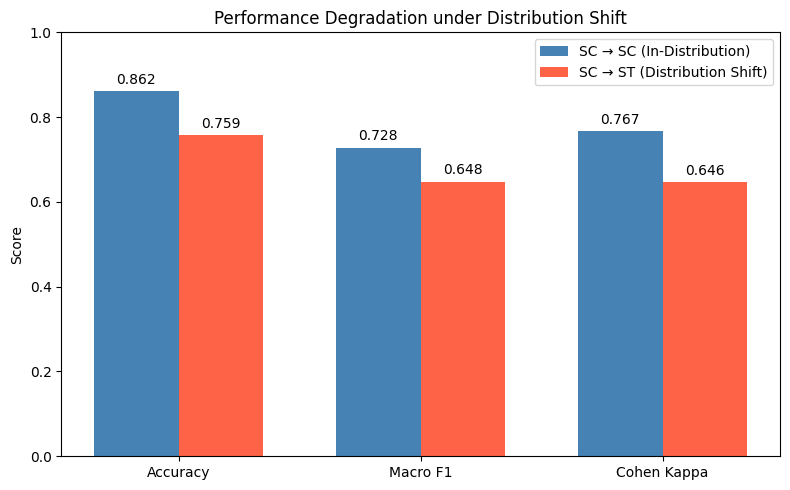

In [23]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]

x = np.arange(len(metrics))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, sc_scores, width, label='SC → SC (In-Distribution)', color='steelblue')
bars2 = ax.bar(x + width/2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')


ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_val])))
labels_sc = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc = confusion_matrix(y_val, y_pred_val, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
disp_sc.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — SC → SC (In-Distribution)')

# Confusion matrix - SC -> ST
unique_st = sorted(np.unique(np.concatenate([y_st, y_pred_st])))
labels_st = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_st]

cm_st = confusion_matrix(y_st, y_pred_st, labels=unique_st)
disp_st = ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=labels_st)

disp_st.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Confusion Matrix — SC → ST (Distribution Shift)')
plt.tight_layout()
plt.show()


### 6.3. Per-Class Analysis

Breakdown of classification performance for each sleep stage to identify which stages degrade most under shift.

In [24]:
from sklearn.metrics import classification_report

if X_sc.size > 0 and 'y_pred_val' in locals():
    print('Per-class F1 scores — SC -> SC (In-Distribution):')
    report_sc = classification_report(
        y_val, y_pred_val,
        target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_val))]
    )
    print(report_sc)
    
    if X_st.size > 0 and 'y_pred_st' in locals():
        print('\nPer-class F1 scores — SC -> ST (Distribution Shift):')
        report_st = classification_report(
            y_st, y_pred_st,
            target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_st))]
        )
        print(report_st)
else:
    print('Validation predictions not available; run training cell first.')

Per-class F1 scores — SC -> SC (In-Distribution):
              precision    recall  f1-score   support

        Wake       0.92      0.98      0.95     35050
          N1       0.43      0.25      0.32      4551
          N2       0.81      0.86      0.84     14679
          N3       0.94      0.75      0.83      2716
         REM       0.78      0.65      0.71      5232

    accuracy                           0.86     62228
   macro avg       0.78      0.70      0.73     62228
weighted avg       0.85      0.86      0.85     62228


Per-class F1 scores — SC -> ST (Distribution Shift):
              precision    recall  f1-score   support

        Wake       0.63      0.97      0.76      4344
          N1       0.38      0.11      0.17      3653
          N2       0.78      0.90      0.84     19851
          N3       0.84      0.66      0.74      6415
         REM       0.80      0.68      0.73      8349

    accuracy                           0.76     42612
   macro avg       0.69    

### 6.4 AUCPR (Area Under the Precision-Recall Curve)

In [ ]:
# Plot AUCPR for all 5 classes (one-vs-rest)
class_ids = sorted(preprocess.STAGE_NAMES.keys())  
class_names = [preprocess.STAGE_NAMES[c] for c in class_ids]

evaluate.plot_aucpr_multiclass(clf, X_val, y_val, X_st, y_st, class_ids, class_names)

---
## 7. Discussion

### Key Findings

**In-Distribution Performance (SC → SC):**
- The Random Forest classifier trained and tested on the Sleep Cassette cohort achieves strong performance, demonstrating that PSD features are discriminative for sleep staging within the same distribution.

**Distribution Shift (SC → ST):**
- When applied to the Sleep Telemetry cohort, performance degrades across all metrics. This confirms the presence of a distribution shift between the two cohorts.
- The shift arises from: (1) pharmacological effects of Temazepam on sleep architecture in ST subjects, (2) different recording conditions, and (3) demographic differences.

**Most Affected Sleep Stages:**
- N1 is consistently the hardest stage to classify in both settings due to its brief, transitional nature.
- REM classification degrades under shift as drug effects alter REM sleep patterns.

### Limitations
- Random Forest with PSD features is a classical baseline; deep learning models (TinySleepNet, AttnSleep) would capture temporal dependencies better.

### Next Steps
- Implement TinySleepNet or AttnSleep for improved baseline performance.
- Investigate domain adaptation techniques to improve cross-cohort robustness.
- Analyze transition errors and calibration under distribution shift.